# Построение рекомендательной системы

В этом блокноте мы познакомимся с датасетом, который содержит достаточно большое количество записей, отражающих историю просмотра и бронирования различных отелей различными пользователями. Затем, на основе этого датасета, мы рассмотрим пример построения простейшей рекомендательной системы.

# Знакомство с датасетом

## Получение данных

In [94]:
import pandas as pd
from pandas import Series,DataFrame
import numpy as np

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

Возьмем небольшой фрагмент данных для ознакомления с датасетом и построим некоторые графики для того, чтобы погрузиться в предметную область и иметь некоторое представление об имеющихся данных.

In [96]:
train_df = pd.read_csv('data/train.csv', nrows=20000)
test_df = train_df[10000:]

In [97]:
train_df.info()
print("----------------------------")
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date_time                  20000 non-null  object 
 1   site_name                  20000 non-null  int64  
 2   posa_continent             20000 non-null  int64  
 3   user_location_country      20000 non-null  int64  
 4   user_location_region       20000 non-null  int64  
 5   user_location_city         20000 non-null  int64  
 6   orig_destination_distance  12599 non-null  float64
 7   user_id                    20000 non-null  int64  
 8   is_mobile                  20000 non-null  int64  
 9   is_package                 20000 non-null  int64  
 10  channel                    20000 non-null  int64  
 11  srch_ci                    19983 non-null  object 
 12  srch_co                    19983 non-null  object 
 13  srch_adults_cnt            20000 non-null  int

In [98]:
# preview the data
train_df.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-07-15 11:37:29,2,3,215,611,21634,NaN,177002,0,1,...,0,2,8271,1,0,1,2,50,696,21
1,2013-03-13 17:23:43,2,3,66,392,32518,143.4471,190606,0,0,...,0,1,8267,1,0,3,2,50,675,17
2,2013-04-30 21:59:08,24,2,3,60,4699,NaN,208044,0,0,...,0,1,8255,1,0,1,6,77,20,9
3,2013-11-22 13:48:19,2,3,66,322,29466,908.9419,268453,0,0,...,0,1,8267,1,0,1,2,50,675,55
4,2014-08-10 18:52:36,11,3,205,155,53927,87.6362,204117,0,0,...,0,1,12943,5,0,1,2,198,399,6


Описание полей датасета


|Column name|Description|Data type|
|-----------|-----------|---------|
|date_time|Timestamp|string|
|site_name|ID of the Expedia point of sale (i.e. Expedia.com, Expedia.co.uk, Expedia.co.jp, ...)|int|
|posa_continent|ID of continent associated with site_name|int|
|user_location_country|The ID of the country the customer is located|int|
|user_location_region|The ID of the region the customer is located|int|
|user_location_city|The ID of the city the customer is located|int|
|orig_destination_distance|Physical distance between a hotel and a customer at the time of search. A null means the distance could not be calculated|double|
|user_id|ID of user|int|
|is_mobile|1 when a user connected from a mobile device, 0 otherwise|tinyint|
|is_package|1 if the click/booking was generated as a part of a package (i.e. combined with a flight), 0 otherwise|int|
|channel|ID of a marketing channel|int|
|srch_ci|Checkin date|string|
|srch_co|Checkout date|string|
|srch_adults_cnt|The number of adults specified in the hotel room|int|
|srch_children_cnt|The number of (extra occupancy) children specified in the hotel room|int|
|srch_rm_cnt|The number of hotel rooms specified in the search|int|
|srch_destination_id|ID of the destination where the hotel search was performed|int|
|srch_destination_type_id|Type of destination|int|
|hotel_continent|Hotel continent|int|
|hotel_country|Hotel country|int|
|hotel_market|Hotel market|int|
|is_booking|1 if a booking, 0 if a click|tinyint|
|cnt|Numer of similar events in the context of the same user session|bigint|
|hotel_cluster|ID of a hotel cluster|int|

## Предобработка данных

В качестве первого шага очистим данные, выполним предварительную обработку и проведем разведочный анализ для того, чтобы сформировать представление о процедуре выбора отеля.


* Удалим пользователей, которые не забронировали отель
* Определим запросы пользователей, относящиеся к конкретному типу направления (месту пребывания)
* orig_destination_distance содержит значения NaN
* Рассмотрим даты заезда и выезда, чтобы узнать продолжительность пребывания для каждой записи в тренировочном наборе.


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70],
 [Text(0, 0, '66'),
  Text(1, 0, '205'),
  Text(2, 0, '69'),
  Text(3, 0, '46'),
  Text(4, 0, '215'),
  Text(5, 0, '3'),
  Text(6, 0, '133'),
  Text(7, 0, '70'),
  Text(8, 0, '1'),
  Text(9, 0, '23'),
  Text(10, 0, '231'),
  Text(11, 0, '154'),
  Text(12, 0, '77'),
  Text(13, 0, '194'),
  Text(14, 0, '68'),
  Text(15, 0, '179'),
  Text(16, 0, '93'),
  Text(17, 0, '115'),
  Text(18, 0, '80'),
  Text(19, 0, '119'),
  Text(20, 0, '48'),
  Text(21, 0, '28'),
  Text(22, 0, '225'),
  Text(23, 0, '0'),
  Text(24, 0, '26'),
  Text(25, 0, '32'),
  Text(26, 0, '195'),
  Text(27, 0, '52'

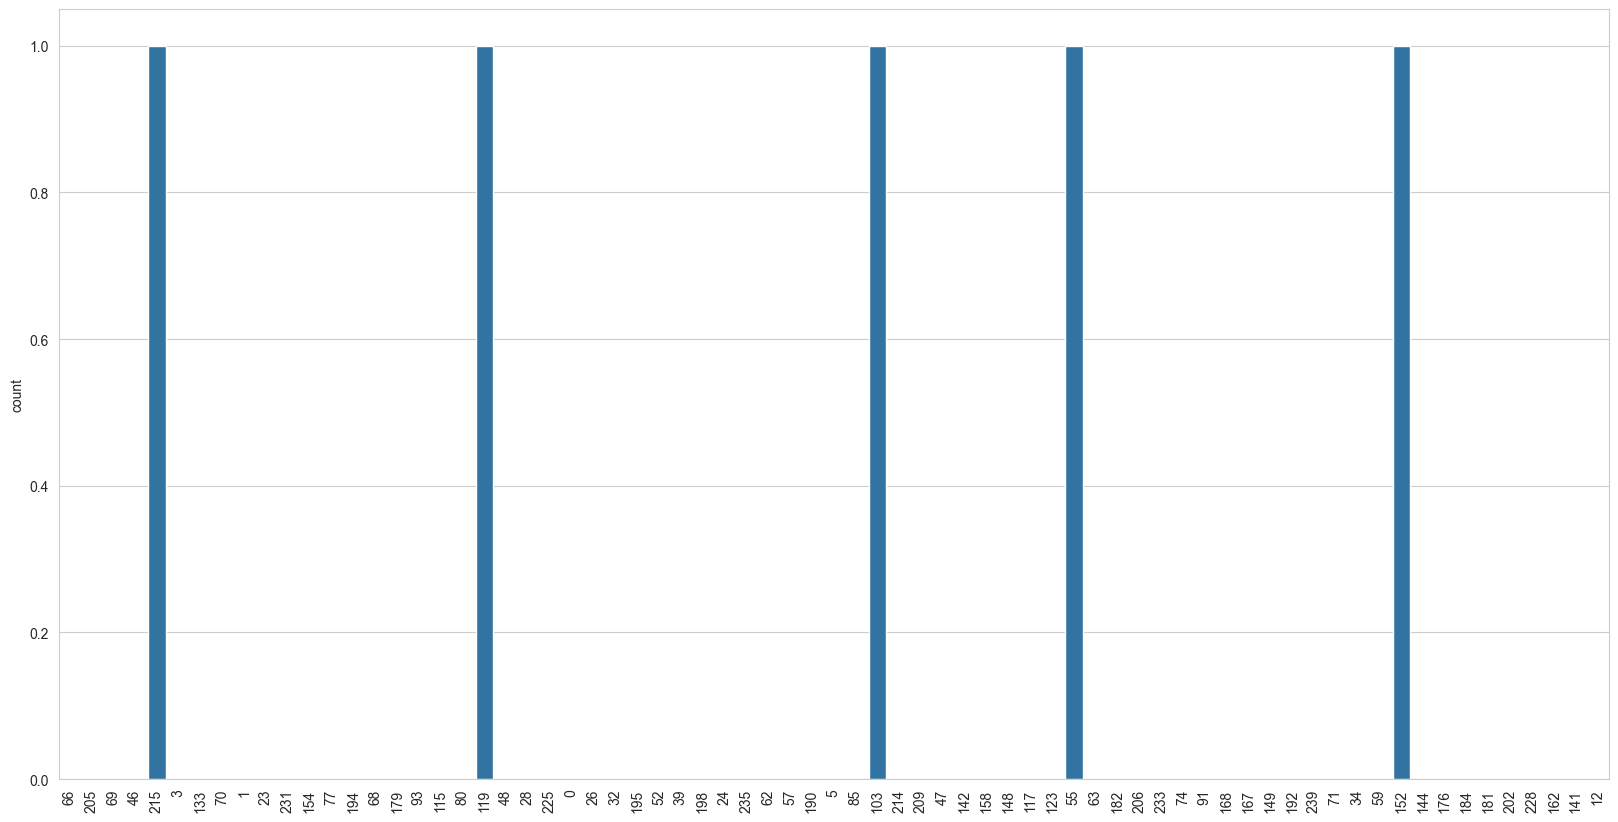

In [99]:

from matplotlib import rcParams

# Plot
bookings_df = train_df[train_df["is_booking"] == 1]

# figure size in inches
rcParams['figure.figsize'] = 20,10
# Из каких стран чаще всего едут клиенты?
sns.countplot(bookings_df['user_location_country'], order = bookings_df['user_location_country'].value_counts().index)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88],
 [Text(0, 0, '50'),
  Text(1, 0, '198'),
  Text(2, 0, '8'),
  Text(3, 0, '70'),
  Text(4, 0, '105'),
  Text(5, 0, '204'),
  Text(6, 0, '182'),
  Text(7, 0, '77'),
  Text(8, 0, '144'),
  Text(9, 0, '171'),
  Text(10, 0, '99'),
  Text(11, 0, '126'),
  Text(12, 0, '48'),
  Text(13, 0, '82'),
  Text(14, 0, '168'),
  Text(15, 0, '68'),
  Text(16, 0, '106'),
  Text(17, 0, '104'),
  Text(18, 0, '163'),
  Text(19, 0, '151'),
  Text(20, 0, '51'),
  Text(21, 0, '63'),
  Text(22, 0

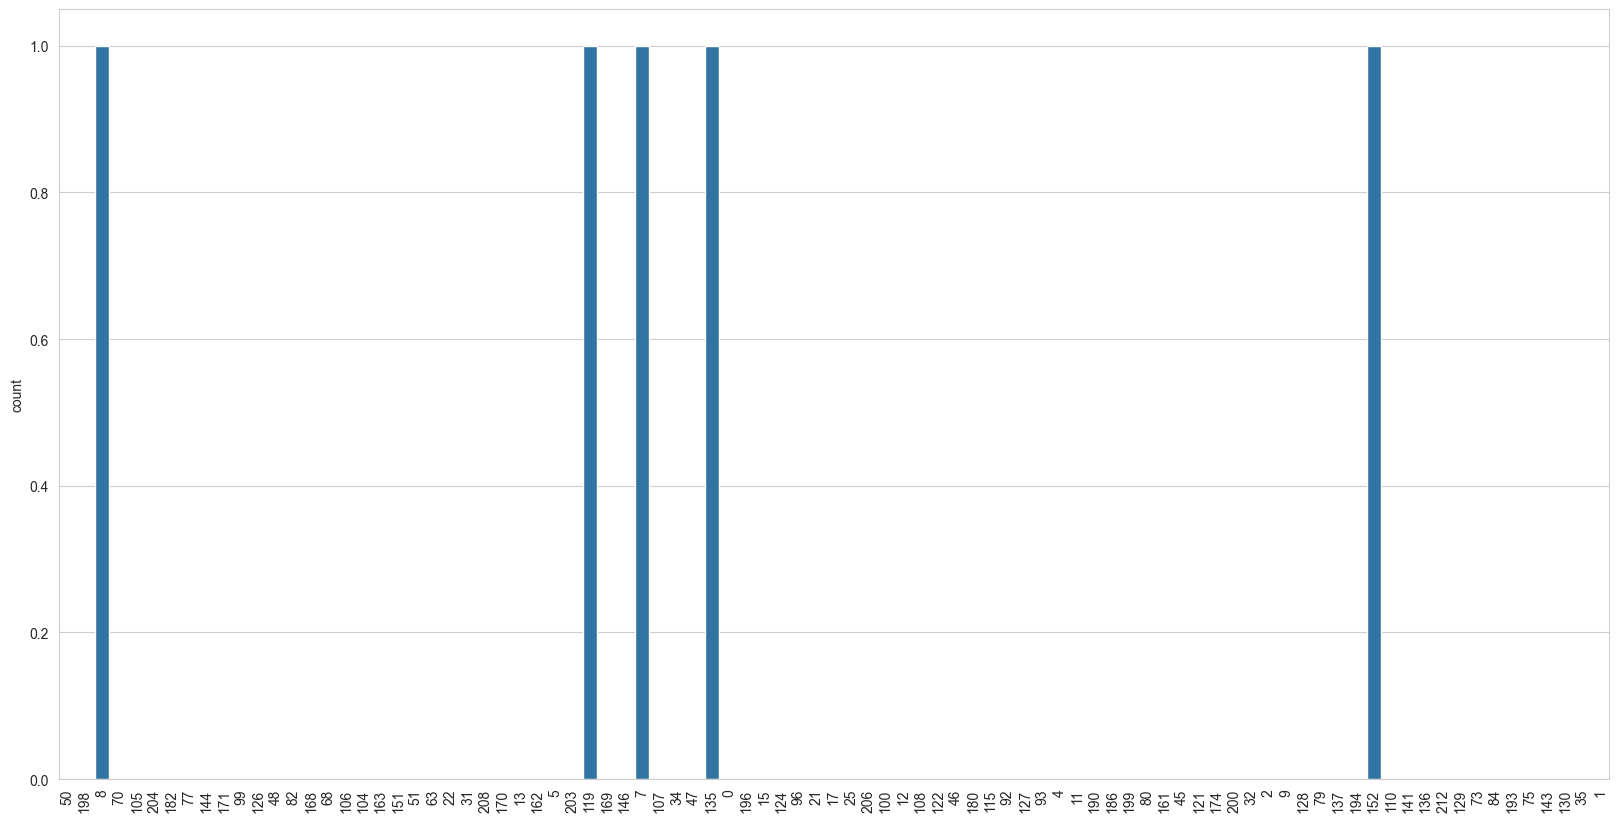

In [100]:
#В какие страны чаще всего ездят клиенты?
sns.countplot(bookings_df['hotel_country'], order = bookings_df['hotel_country'].value_counts().index)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99],
 [Text(0, 0, '50'),
  Text(1, 0, '8'),
  Text(2, 0, '105'),
  Text(3, 0, '198'),
  Text(4, 0, '163'),
  Text(5, 0, '70'),
  Text(6, 0, '204'),
  Text(7, 0, '77'),
  Text(8, 0, '47'),
  Text(9, 0, '51'),
  Text(10, 0, '128'),
  Text(11, 0, '146'),
  Text(12, 0, '106'),
  Text(13, 0, '144'),
  Text(14, 0, '96'),
  Text(15, 0, '31'),
  Text(16, 0, '171'),
  Text(17, 0, '127'),
  Text(18, 0, '82'),
  Text(19, 

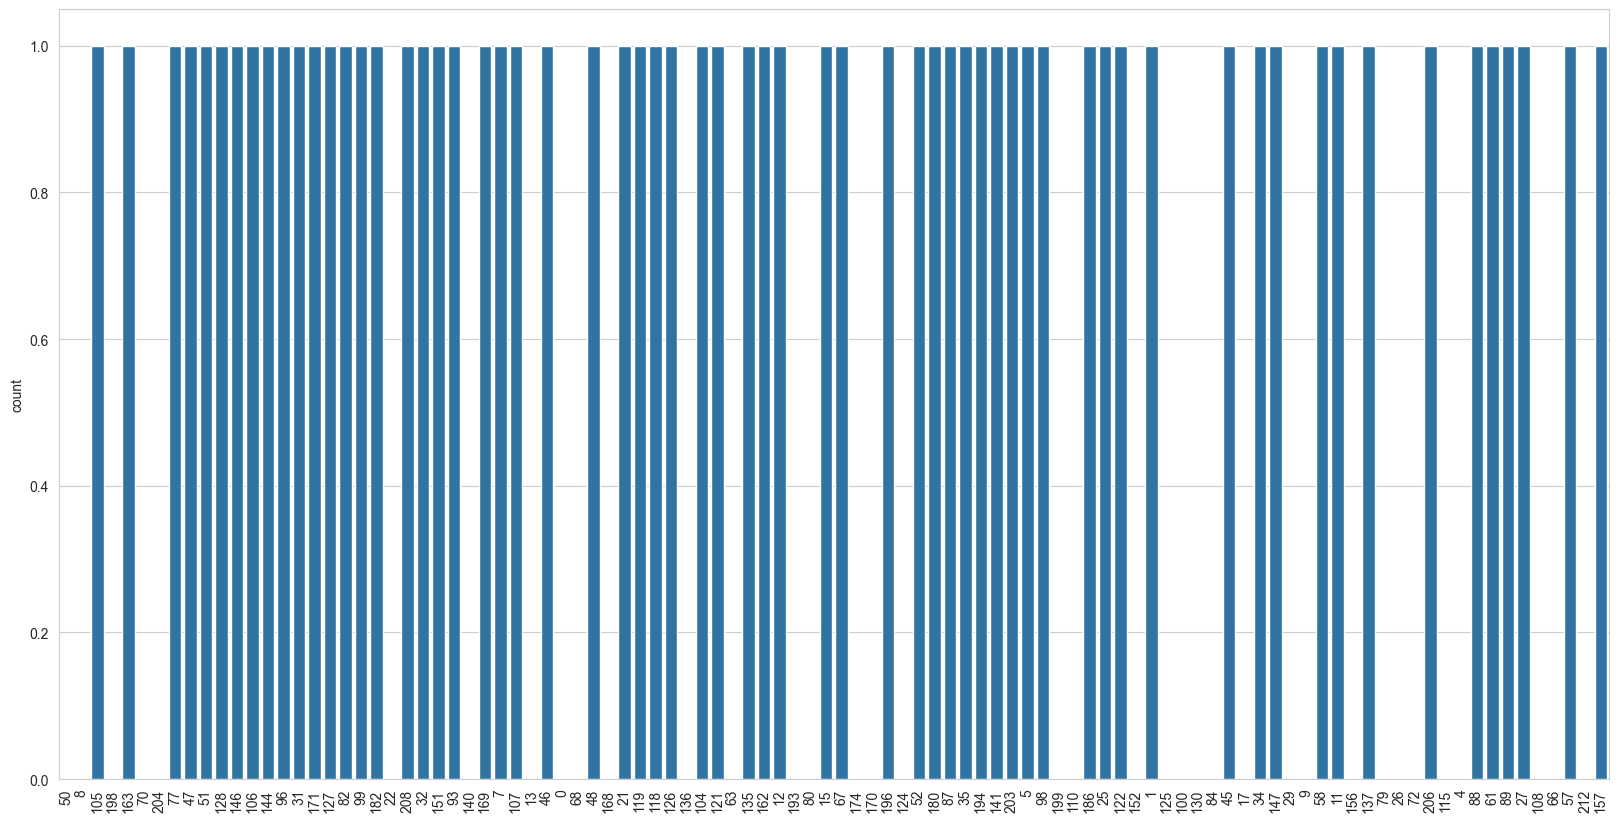

In [101]:
# Куда едет большинство клиентов из определенной страны?
user_country_id = 66
country_customers = train_df[train_df["user_location_country"] == user_country_id]
sns.countplot(country_customers['hotel_country'], order = country_customers['hotel_country'].value_counts().index)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99],
 [Text(0, 0, '91'),
  Text(1, 0, '41'),
  Text(2, 0, '48'),
  Text(3, 0, '64'),
  Text(4, 0, '65'),
  Text(5, 0, '59'),
  Text(6, 0, '46'),
  Text(7, 0, '37'),
  Text(8, 0, '97'),
  Text(9, 0, '98'),
  Text(10, 0, '5'),
  Text(11, 0, '42'),
  Text(12, 0, '70'),
  Text(13, 0, '9'),
  Text(14, 0, '30'),
  Text(15, 0, '95'),
  Text(16, 0, '21'),
  Text(17, 0, '18'),
  Text(18, 0, '58'),
  Text(19, 0, '25'),
 

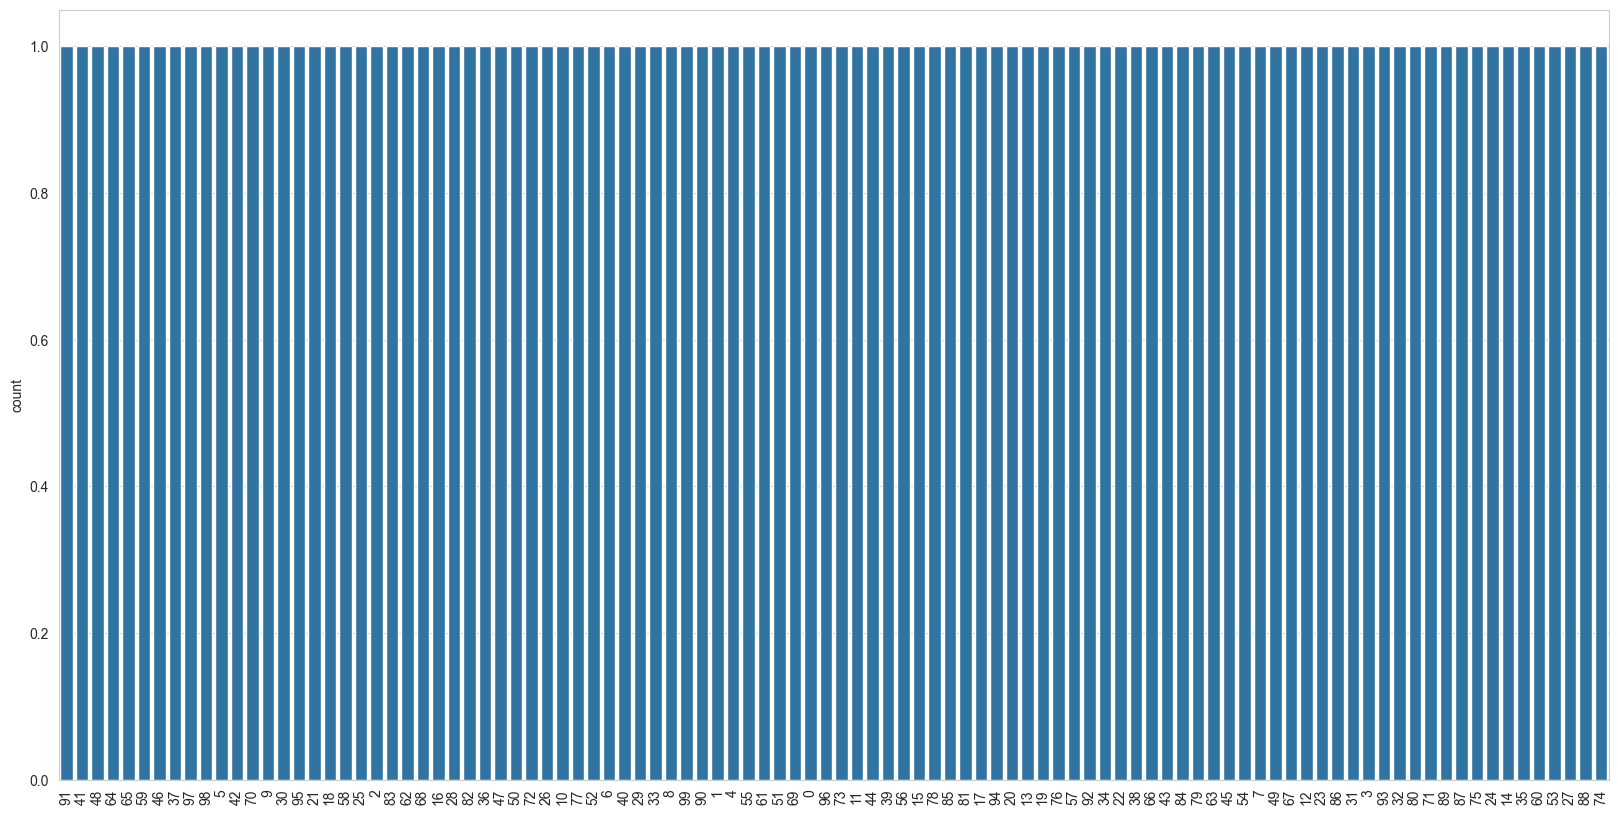

In [102]:
# График частот для каждого hotel_clusters
sns.countplot(train_df["hotel_cluster"], order = train_df["hotel_cluster"].value_counts().index)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99],
 [Text(0, 0, '91'),
  Text(1, 0, '41'),
  Text(2, 0, '48'),
  Text(3, 0, '65'),
  Text(4, 0, '18'),
  Text(5, 0, '42'),
  Text(6, 0, '52'),
  Text(7, 0, '95'),
  Text(8, 0, '70'),
  Text(9, 0, '21'),
  Text(10, 0, '37'),
  Text(11, 0, '9'),
  Text(12, 0, '83'),
  Text(13, 0, '72'),
  Text(14, 0, '68'),
  Text(15, 0, '47'),
  Text(16, 0, '26'),
  Text(17, 0, '98'),
  Text(18, 0, '28'),
  Text(19, 0, '50'),


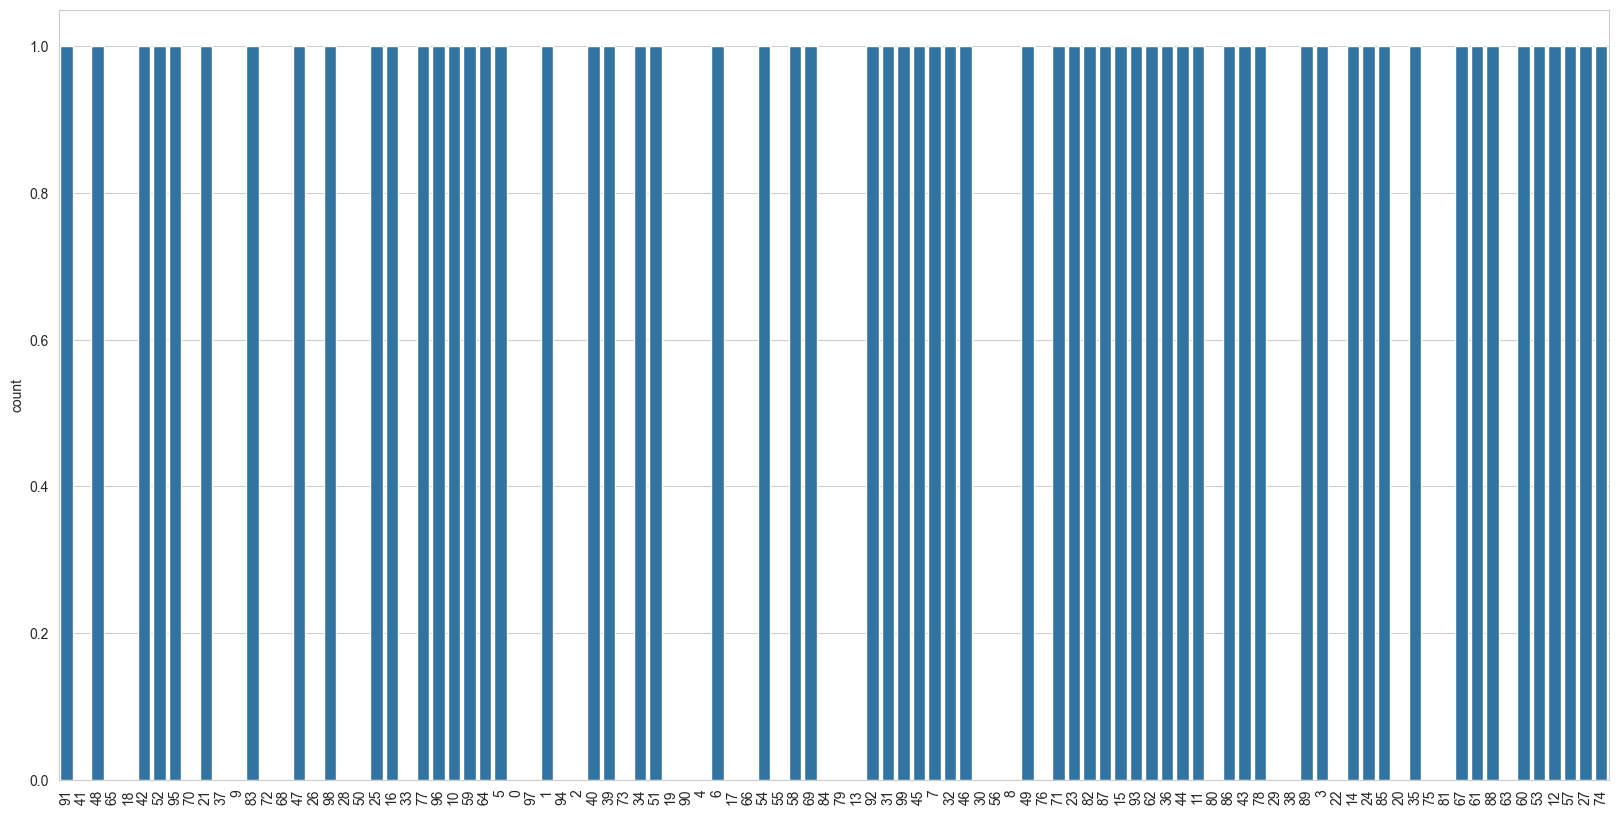

In [103]:
# Отели какого кластера наиболее часто бронируют клиенты из определенной страны?
customer_clusters = train_df[train_df["user_location_country"] == user_country_id]["hotel_cluster"]
sns.countplot(customer_clusters, order = customer_clusters.value_counts().index)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96],
 [Text(0, 0, '91'),
  Text(1, 0, '41'),
  Text(2, 0, '48'),
  Text(3, 0, '70'),
  Text(4, 0, '42'),
  Text(5, 0, '18'),
  Text(6, 0, '98'),
  Text(7, 0, '95'),
  Text(8, 0, '1'),
  Text(9, 0, '83'),
  Text(10, 0, '72'),
  Text(11, 0, '47'),
  Text(12, 0, '21'),
  Text(13, 0, '77'),
  Text(14, 0, '28'),
  Text(15, 0, '16'),
  Text(16, 0, '50'),
  Text(17, 0, '56'),
  Text(18, 0, '39'),
  Text(19, 0, '94'),
  Text(20, 0, '37'

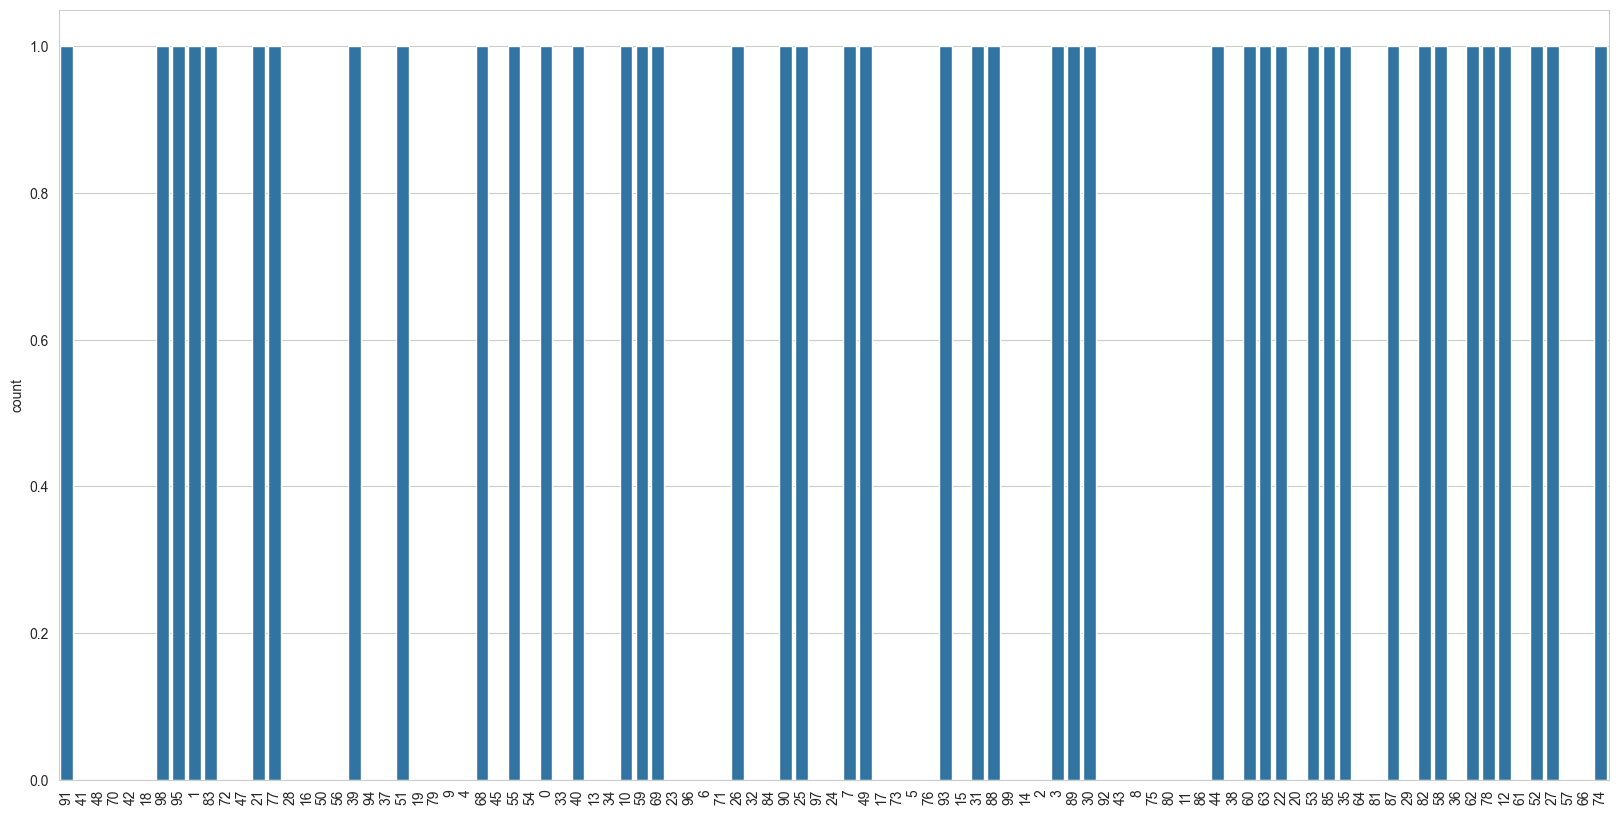

In [104]:
# Какие гостиничные кластеры наиболее часто встречаются в стране?
country_id = 50
country_clusters = train_df[train_df["hotel_country"] == country_id]["hotel_cluster"]
sns.countplot(country_clusters, order = country_clusters.value_counts().index)
plt.xticks(rotation=90)

<Axes: ylabel='count'>

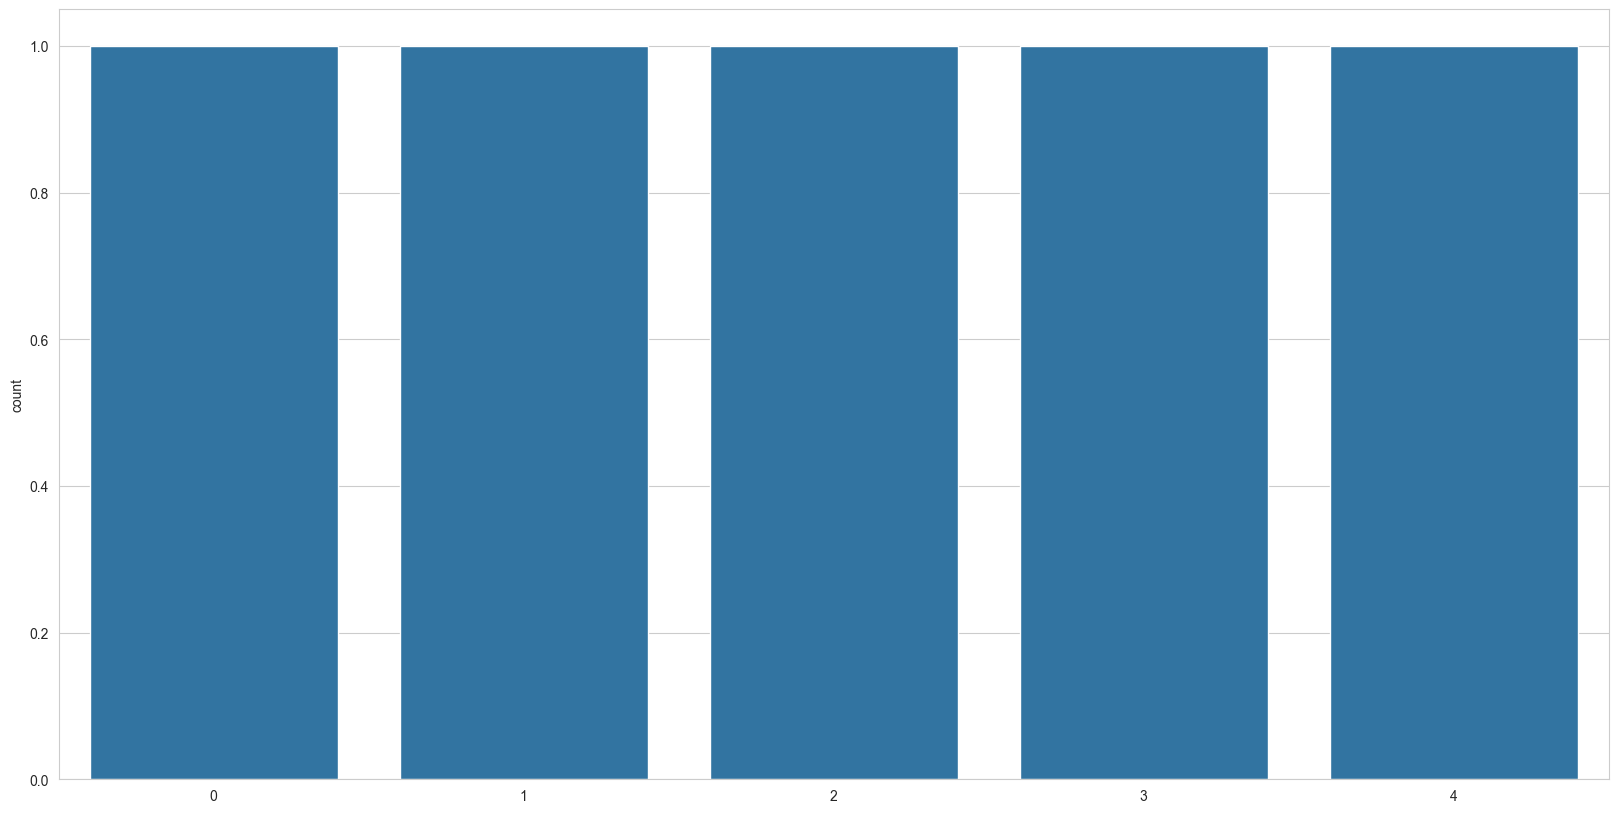

In [105]:
# Частота для каждого posa_continent
sns.countplot(train_df['posa_continent'], order=[0,1,2,3,4])

<Axes: xlabel='posa_continent', ylabel='count'>

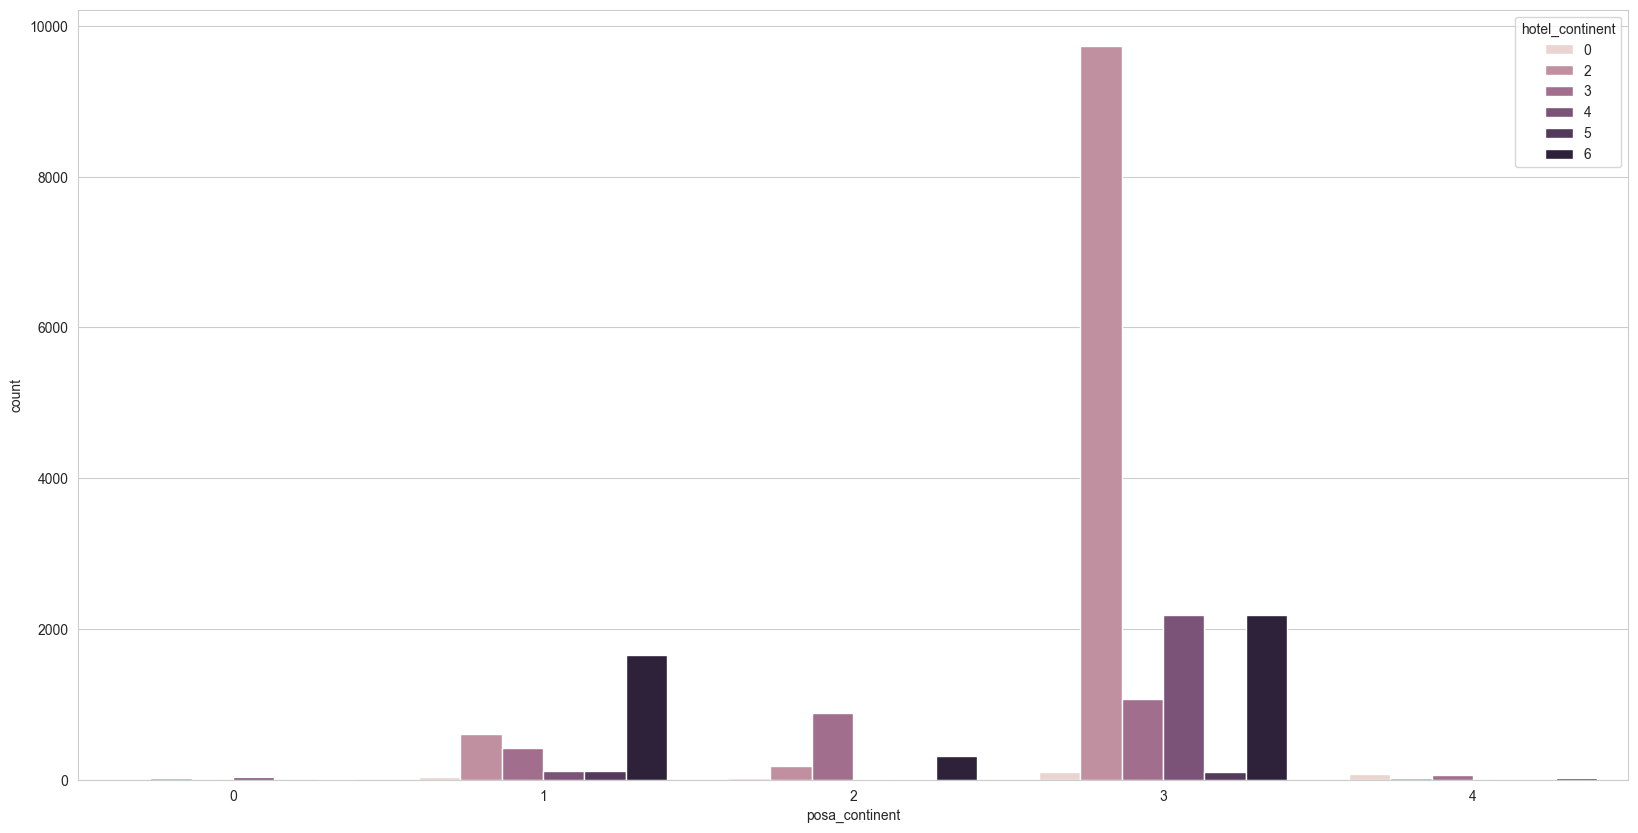

In [106]:
# Частота для каждого posa_continent с разбивкой по hotel_continent
sns.countplot(x='posa_continent', data=train_df, order=[0,1,2,3,4], hue='hotel_continent')

<Axes: xlabel='hotel_continent', ylabel='count'>

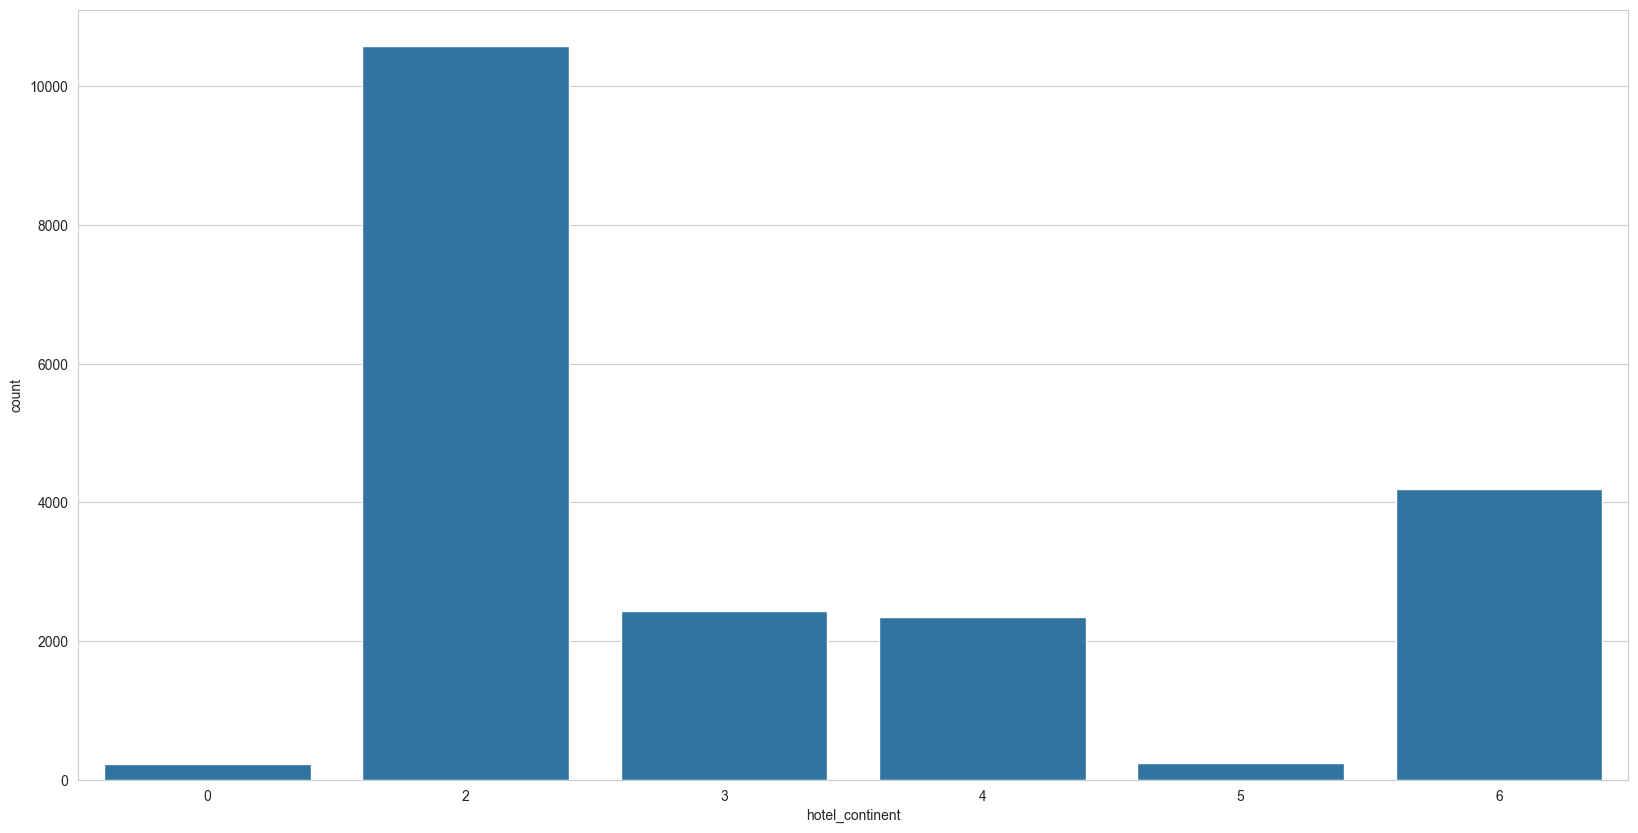

In [107]:
# Частота для каждого hotel_continent
sns.countplot(x='hotel_continent', data=train_df,order=[0,2,3,4,5,6])

<Axes: xlabel='hotel_continent', ylabel='count'>

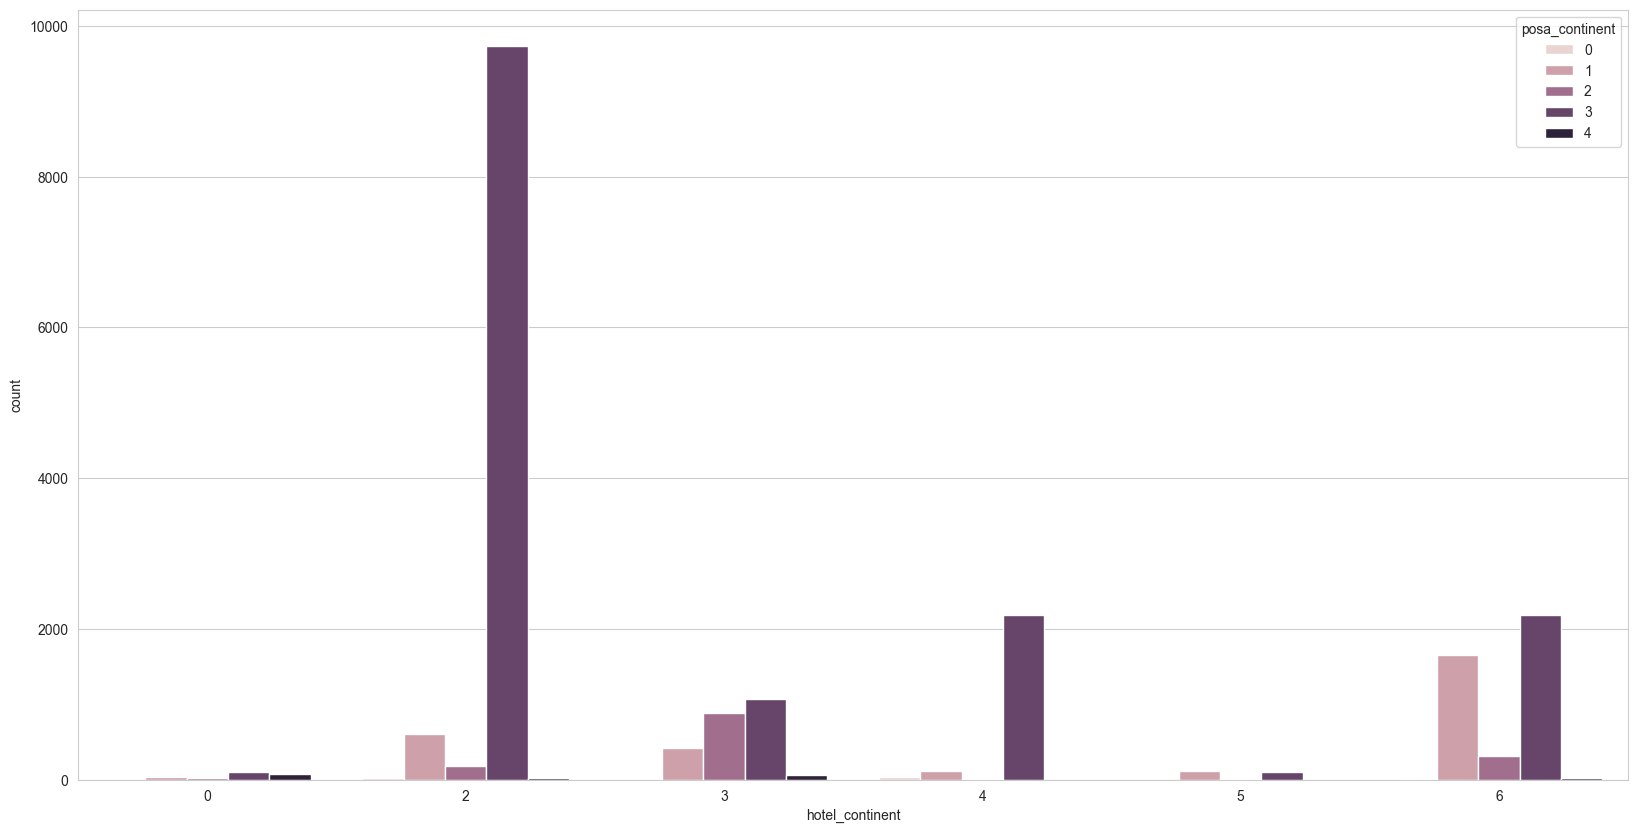

In [108]:
# Частота для каждого hotel_continent с разбивкой по posa_continent
sns.countplot(x='hotel_continent', hue='posa_continent', data=train_df, order=[0,2,3,4,5,6])

<Axes: xlabel='is_mobile', ylabel='count'>

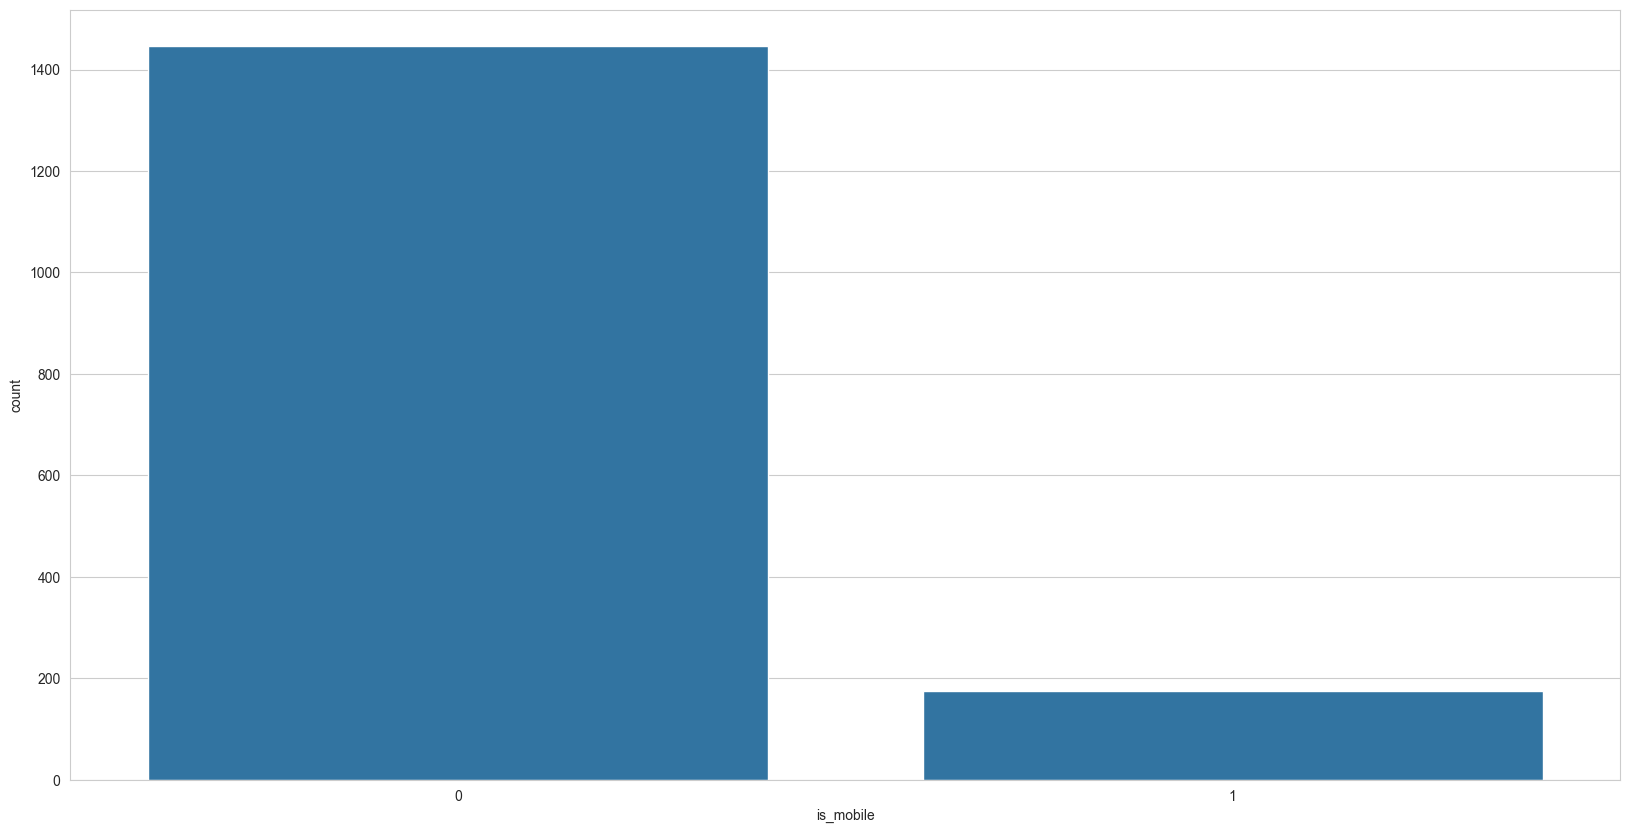

In [109]:
# Частота бронирований с мобильных телефонов
sns.countplot(x='is_mobile',data=bookings_df, order=[0,1])

<Axes: xlabel='is_package', ylabel='count'>

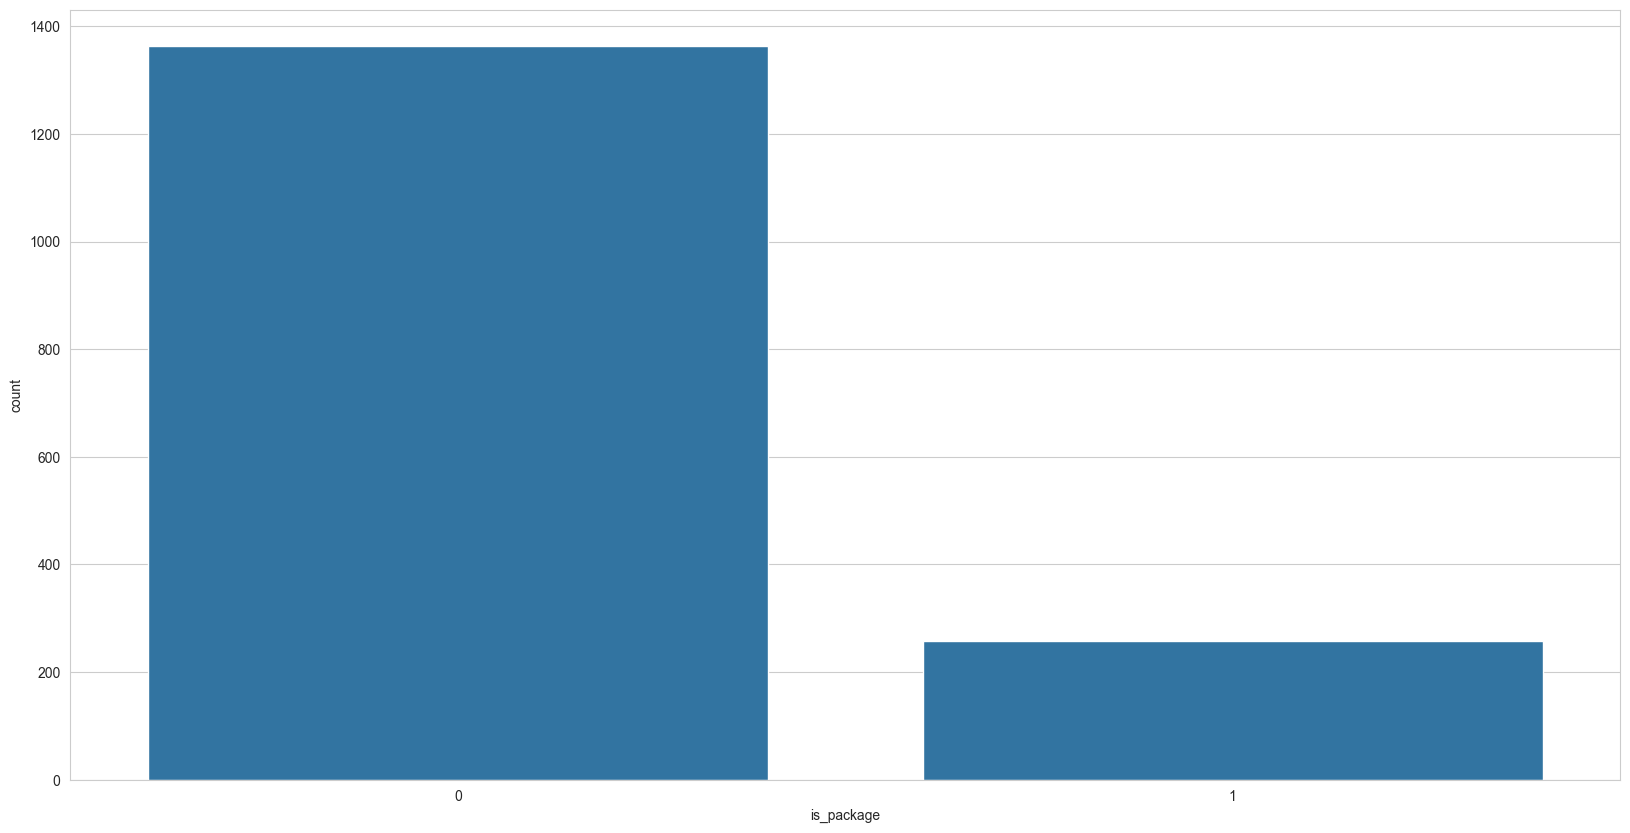

In [110]:
# Частота бронирований отелей вместе с другими услугами (is_package)
sns.countplot(x='is_package',data=bookings_df, order=[0,1])

<Axes: xlabel='channel', ylabel='count'>

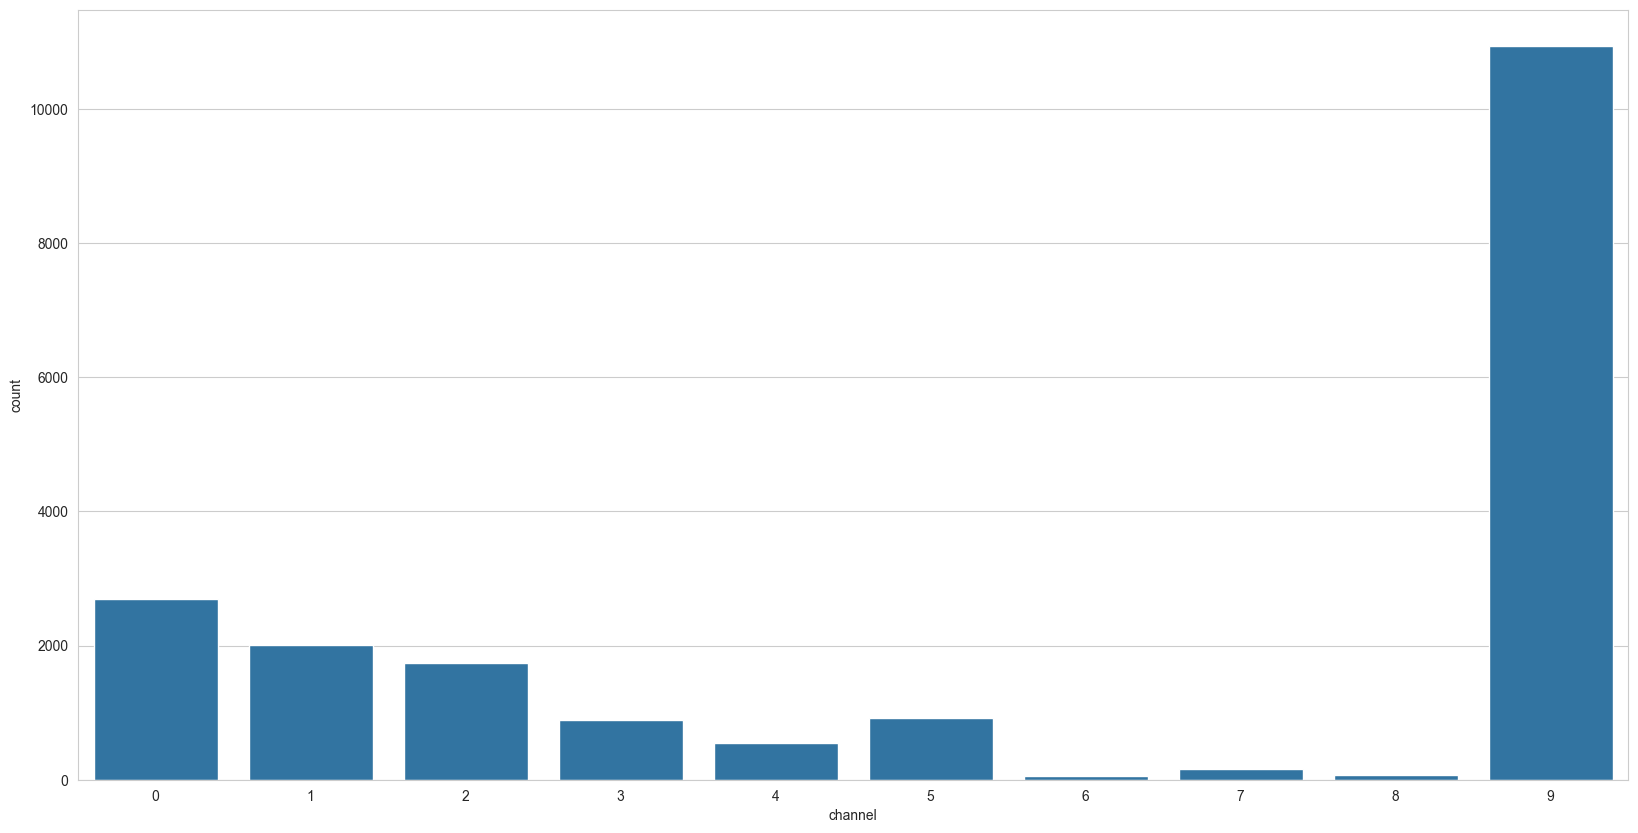

In [111]:
# Наиболее влиятельный канал
sns.countplot(x='channel', order=list(range(0,10)), data=train_df)

<Axes: >

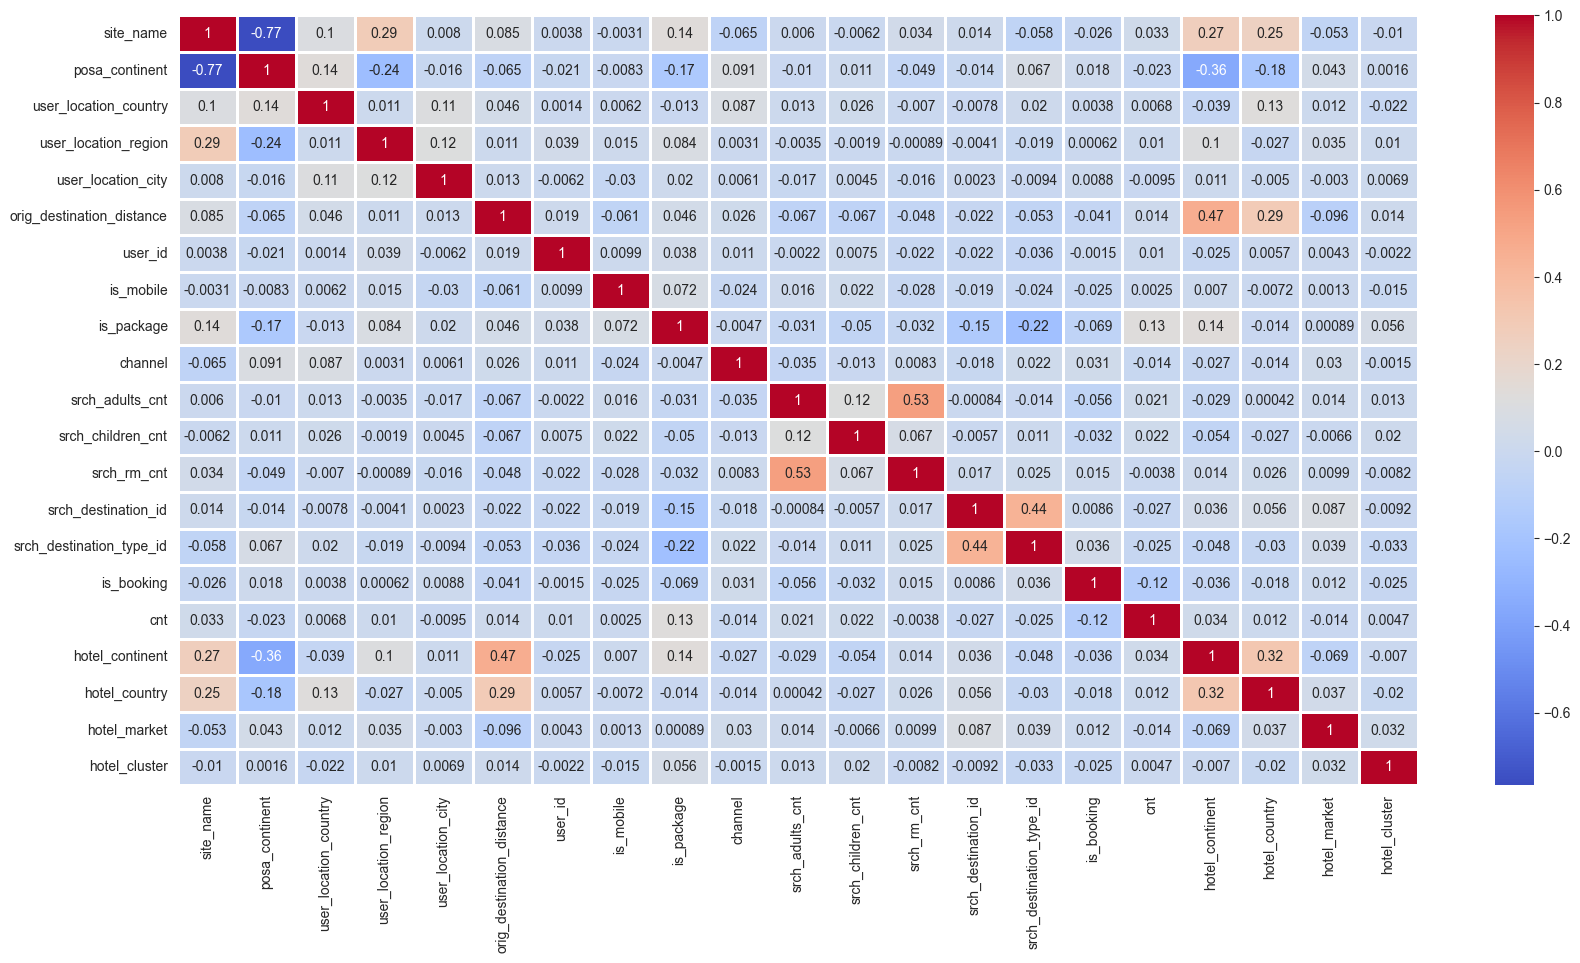

In [112]:
# Select only numeric columns
numeric_df = train_df.select_dtypes(include=[np.number])

# Generate the heatmap
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, linewidths=2)

## Формирование новых признаков

Зачастую бывает удобно сформировать новые признаки на основе уже имеющихся. Эти новые признаки, возможно, будут более ценны с точки зрения использования в предсказании.

Приведем пример такого преобразования

**Дополнительные признаки на основе даты**
* stay_dur: количество дней пребывания
* no_of_days_bet_booking: количество дней между бронированием и
  * Cin_day: Днем Check-in
  * Cin_month: Месяцем Check-in
  * Cin_year: Годом Check-in

In [113]:
# Function to convert date object into relevant attributes
def convert_date_into_days(df):
    df['srch_ci'] = pd.to_datetime(df['srch_ci'])
    df['srch_co'] = pd.to_datetime(df['srch_co'])
    df['date_time'] = pd.to_datetime(df['date_time'])

    df['stay_dur'] = (df['srch_co'] - df['srch_ci']).astype('timedelta64[D]')
    df['no_of_days_bet_booking'] = (df['srch_ci'] - df['date_time']).astype('timedelta64[D]')

    # For hotel check-in
    # Month, Year, Day
    df['Cin_day'] = df["srch_ci"].apply(lambda x: x.day)
    df['Cin_month'] = df["srch_ci"].apply(lambda x: x.month)
    df['Cin_year'] = df["srch_ci"].apply(lambda x: x.year)


In [114]:
convert_date_into_days(train_df)
convert_date_into_days(test_df)

ValueError: Cannot convert from timedelta64[ns] to timedelta64[D]. Supported resolutions are 's', 'ms', 'us', 'ns'

In [ ]:
# Количество бронировний по месяцам
sns.countplot('Cin_month',data=train_df[train_df["is_booking"] == 1],order=list(range(1,13)))

In [ ]:
# Количество бронировний по дням месяца
sns.countplot('Cin_day',data=train_df[train_df["is_booking"] == 1],order=list(range(1,32)))

In [ ]:
# Частоты длительностей пребывания
sns.countplot('stay_dur',data=train_df[train_df["is_booking"] == 1])

In [ ]:
# Уберем ненужные признаки, которые не будут полезны для анализа и предсказания
#test_user_id = test_df['user_id']
columns = ['date_time', 'srch_ci','user_id','srch_destination_type_id','srch_destination_id', 'site_name', 'user_location_region', 'user_location_city',
                              'user_id', 'srch_co', 'srch_adults_cnt', 'srch_children_cnt', 'srch_rm_cnt']
train_df.drop(columns=columns,axis=1,inplace=True)
test_df.drop(columns=columns,axis=1,inplace=True)

In [ ]:
# Определим процент значений NaN по каждому признаку
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum()/train_df['hotel_cluster'].count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

In [ ]:
# Заменим NaN датой с наибольшей частотой
train_df['Cin_day'] = train_df['Cin_day'].fillna(26.0)
train_df['Cin_month'] = train_df['Cin_month'].fillna(8.0)
train_df['Cin_year'] = train_df['Cin_year'].fillna(2014.0)
train_df['stay_dur'] = train_df['stay_dur'].fillna(1.0)
train_df['no_of_days_bet_booking'] = train_df['no_of_days_bet_booking'].fillna(0.0)

# Заменим NaN на среднее значение по столбцу
train_df['orig_destination_distance'].fillna(train_df['orig_destination_distance'].mean(), inplace=True)

## Дополнительная информация

Кроме данных о бронированиях имеется также дополнительная информация о латентных признаках поисковых запросов. Файл `destinations.csv` можно найти по [ссылке](https://disk.yandex.ru/d/UY99dlHYjLASvw). Структура файла имеет вид:

|Column name	|Description|	Data type|
|-------------|-----------|----------|
|srch_destination_id|	ID of the destination where the hotel search was performed|	int|
|d1-d149|latent description of search regions|	double|

# Предсказание

Переходим непосредственно к построению рекомендательной системы. Напомним, что основная задача — порекомендовать пользователю отель в месте его назначения.

## Простое решение
Мы рассмотрим очень простое решение, реализованное с помощью pandas. В качестве рекомендации мы будем использовать «самый популярный местный отель».

Обращаем внимание, что в данном примере мы не только не используем все рассмотренные ранее преобразования данных, но и сокращаем количество признаков до двух `srch_destination_id`,`is_booking`. Откликом будет `hotel_cluster`. При этом для обучения мы используем весь датасет, из которого выделим небольшой фрагмент тестовых данных.

**Шаг 1**

Считаем данные, используя только необходимые столбцы. Явное указание типов данных (dtypes) помогает уменьшить объем используемой памяти.
Файл читается фрагментами по 100к строк каждый.

**Шаг 2**

На втором шаге мы вычисляем «релевантность» гостиничного кластера с помощью взвешенной суммы бронирований и кликов.

**Шаг 3**

Считываем тестовые данные и формируем рекомендации.

**Шаг 4**

Оцениваем результаты.

In [ ]:
from tqdm.notebook import tqdm
# Step 1
train = pd.read_csv('data/train.csv',
                    dtype={'is_booking':bool,'srch_destination_id':np.int32, 'hotel_cluster':np.int32},
                    usecols=['srch_destination_id','is_booking','hotel_cluster'],
                    chunksize=100000)

# Вот тут сформируем тестовый набор данных как последний chunk
test = next(train)

aggs = []
for chunk in tqdm(train, total = 339):
    agg = chunk.groupby(['srch_destination_id', 'hotel_cluster'])['is_booking'].agg(['sum','count'])
    agg.reset_index(inplace=True)
    aggs.append(agg)
aggs = pd.concat(aggs, axis=0)
aggs.head()

In [ ]:
# Step 2
CLICK_WEIGHT = 0.05
agg = aggs.groupby(['srch_destination_id','hotel_cluster']).sum().reset_index()
agg['count'] -= agg['sum']
agg = agg.rename(columns={'sum':'bookings','count':'clicks'})
agg['relevance'] = agg['bookings'] + CLICK_WEIGHT * agg['clicks']
agg.head()

In [ ]:
# Функция для определения наиболее популяных отелей для конкретного srch_destination_id
def most_popular(group, n_max=5):
    relevance = group['relevance'].values
    hotel_cluster = group['hotel_cluster'].values
    most_popular = hotel_cluster[np.argsort(relevance)[::-1]][:n_max]
    return np.array_str(most_popular)[1:-1] # remove square brackets

In [ ]:
# Получаем наиболее популярные кластеры отелей для всех направлений
most_pop = agg.groupby(['srch_destination_id']).apply(most_popular)
most_pop = pd.DataFrame(most_pop).rename(columns={0:'hotel_cluster'})
most_pop.head()

In [ ]:
# gold сохраним как истинные значения
gold = test.copy()
test = test.drop(columns=['hotel_cluster'])

In [ ]:
# Step 3: Формируем предсказания
test = test.merge(most_pop, how='left',left_on='srch_destination_id',right_index=True)
test.head()

In [ ]:
# Проверим, сколько isnull значений получилось
test.hotel_cluster.isnull().sum()

In [ ]:
# Заменим NaN на наиболее популярные в целом гостиничные кластеры.
most_pop_all = agg.groupby('hotel_cluster')['relevance'].sum().nlargest(5).index
most_pop_all = np.array_str(most_pop_all.to_numpy())[1:-1]
print(most_pop_all)
test.hotel_cluster.fillna(most_pop_all,inplace=True)
#test.hotel_cluster.to_csv('submission.csv',header=True, index_label='id')

Осталось выполнить оценку, посмотрим на то, что должно получиться (gold) и на то, что получилось (test).

In [ ]:
gold.head()

In [ ]:
test.head()

Оценивать будем посредством метрики [MAP@5.](https://sdsawtelle.github.io/blog/output/mean-average-precision-MAP-for-recommender-systems.html)

In [ ]:
def apk(actual, predicted, k=10):
    if not actual:
        return 0.0

    if len(predicted)>k:
        predicted = predicted[:k]

    score = 0.0
    num_hits = 0.0

    for i,p in enumerate(predicted):
        # first condition checks whether it is valid prediction
        # second condition checks if prediction is not repeated
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i+1.0)

    return score / min(len(actual), k)

def mapk(actual, predicted, k=10):
    return np.mean([apk(a,p,k) for a,p in zip(actual, predicted)])

In [ ]:
actual = [[x] for x in gold.hotel_cluster]
predicted = [x.split(' ') for x in test.hotel_cluster]
predicted = [[int(m) for m in x if m != ''] for x in predicted]

In [ ]:
print('MAP@5 = ', round(mapk(actual, predicted, 5),3))